In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.optimize import linprog
from scipy.optimize import minimize
import yfinance as yf

# Portfolio Creation and Analysis

<br>
<div class="alert alert-block alert-info"><b>
In this project we will explore creating an Investment Portfolio from stocks chosen randomly from different industries
and will optimize this based on the risk and returns. In the code cells below we have just selected the stock tickers
to be used and only use the Close price column, we then merge and rename the columns to the relevant name of the ticker.
We also check if there are any missing values and use forward filling instead of removing the data - in time series and 
finance it is always better to forward/backward fill as removing data points can impact the models and outcomes of data projects.
</b></div>
</br>

In [3]:
df1 = yf.download('JPM', period = '6mo')['Close']
df2 = yf.download('ORCL', period = '6mo')['Close']
df3 = yf.download('MCD', period = '6mo')['Close']
df4 = yf.download('F', period = '6mo')['Close']
df5 = yf.download('DIS', period = '6mo')['Close']
df6 = yf.download('BRK-B', period = '6mo')['Close']
df7 = yf.download('BARC.L', period = '6mo')['Close']
df8 = yf.download('RR.L', period = '6mo')['Close']
df9 = yf.download('AZN.L', period = '6mo')['Close']
df10 = yf.download('BATS.L', period = '6mo')['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [53]:
merged = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10], axis = 1, sort = False)
merged.columns = ['JPChase', 'Oracle', 'McDonalds', 'Ford', 'Disney', 
                  'Berkshire', 'Barclays', 'Rolls-Royce', 'AstraZeneca', 'BAT']
merged.head()

,JPChase,Oracle,McDonalds,Ford,Disney,Berkshire,Barclays,Rolls-Royce,AstraZeneca,BAT
Date,,,,,,,,,,
2026-03-02,294.717255,148.214905,330.717041,13.081641,103.536659,480.170013,437.301086,1353.888794,15250.993164,4616.735840
2026-03-03,297.391449,147.976578,329.932373,12.407531,102.514488,481.359985,422.502716,1302.892944,14931.013672,4462.778320
2026-03-04,296.529785,151.313263,329.505249,12.514997,102.256470,487.480011,430.551819,1362.888062,15087.003906,4525.760742
2026-03-05,290.745544,153.716476,325.244171,12.055821,101.631256,500.399994,416.953339,1289.894043,14773.024414,4386.799316
2026-03-06,286.714447,151.899185,325.850037,11.870196,100.767876,498.980011,404.104767,1264.896118,14499.041992,4280.828125


In [5]:
merged.isna().sum().sum()

24

In [6]:
merged = merged.ffill()
merged.isna().sum().sum()

0

In [7]:
len(merged)

128

In [8]:
returns = pd.DataFrame(index = merged.index[1:])

for i in merged:
    current_returns = np.log(merged[i]).diff()
    returns[i] = current_returns.iloc[1:] * 100

returns.head()

,JPChase,Oracle,McDonalds,Ford,Disney,Berkshire,Barclays,Rolls-Royce,AstraZeneca,BAT
Date,,,,,,,,,,
2026-03-03,0.903284,-0.160928,-0.237545,-5.290620,-0.992161,0.247516,-3.442607,-3.839391,-2.120412,-3.391641
2026-03-04,-0.290161,2.229827,-0.129542,0.862411,-0.252007,1.263389,1.887181,4.501889,1.039320,1.401417
2026-03-05,-1.969920,1.575757,-1.301609,-3.738008,-0.613294,2.615848,-3.209337,-5.504595,-2.103086,-3.118581
2026-03-06,-1.396170,-1.189280,0.186107,-1.551690,-0.853152,-0.284173,-3.130015,-1.957008,-1.872027,-2.445340
2026-03-09,0.151890,-0.919496,0.831740,0.328676,0.118110,-0.357365,-1.684275,-2.117123,-0.400802,0.628568


In [9]:
mean_returns = returns.mean()
mean_returns

JPChase        0.152326
Oracle         0.013876
McDonalds     -0.174436
Ford           0.046645
Disney         0.033961
Berkshire      0.039699
Barclays       0.093760
Rolls-Royce    0.096186
AstraZeneca   -0.181325
BAT           -0.083542
dtype: float64

In [10]:
covariance = returns.cov()
covariance

,JPChase,Oracle,McDonalds,Ford,Disney,Berkshire,Barclays,Rolls-Royce,AstraZeneca,BAT
JPChase,1.729803,0.395190,0.180396,0.231395,0.388997,0.203747,1.184120,1.429289,0.192626,-0.094023
Oracle,0.395190,14.181013,-1.062555,1.720703,0.534397,-0.455645,1.022687,1.255455,-1.947758,-1.892300
McDonalds,0.180396,-1.062555,1.664803,-0.069441,0.858499,0.471360,-0.074187,0.527860,0.802078,0.566698
Ford,0.231395,1.720703,-0.069441,7.006492,0.905519,-0.098322,1.804115,2.760219,0.478879,0.636045
Disney,0.388997,0.534397,0.858499,0.905519,2.685961,0.432842,0.703218,1.332014,0.558472,0.551717
Berkshire,0.203747,-0.455645,0.471360,-0.098322,0.432842,0.769737,-0.154843,0.308725,0.196901,0.216113
Barclays,1.184120,1.022687,-0.074187,1.804115,0.703218,-0.154843,4.288135,4.068266,0.553668,-0.150265
Rolls-Royce,1.429289,1.255455,0.527860,2.760219,1.332014,0.308725,4.068266,7.931301,0.747881,-0.072889
AstraZeneca,0.192626,-1.947758,0.802078,0.478879,0.558472,0.196901,0.553668,0.747881,3.516697,1.135580
BAT,-0.094023,-1.892300,0.566698,0.636045,0.551717,0.216113,-0.150265,-0.072889,1.135580,3.261405


In [11]:
covariance_np = covariance.to_numpy()
covariance_np

array([[ 1.72980348,  0.39519027,  0.18039558,  0.23139544,  0.38899745,
         0.20374706,  1.18412002,  1.42928884,  0.19262636, -0.09402272],
       [ 0.39519027, 14.18101302, -1.06255528,  1.72070282,  0.53439651,
        -0.45564492,  1.02268718,  1.25545507, -1.94775762, -1.89230022],
       [ 0.18039558, -1.06255528,  1.66480309, -0.06944069,  0.85849864,
         0.47136001, -0.0741869 ,  0.52785986,  0.80207819,  0.56669766],
       [ 0.23139544,  1.72070282, -0.06944069,  7.00649192,  0.9055186 ,
        -0.09832178,  1.80411531,  2.76021851,  0.4788787 ,  0.6360448 ],
       [ 0.38899745,  0.53439651,  0.85849864,  0.9055186 ,  2.68596077,
         0.43284246,  0.70321762,  1.33201449,  0.55847184,  0.55171703],
       [ 0.20374706, -0.45564492,  0.47136001, -0.09832178,  0.43284246,
         0.76973719, -0.15484301,  0.30872545,  0.19690065,  0.21611287],
       [ 1.18412002,  1.02268718, -0.0741869 ,  1.80411531,  0.70321762,
        -0.15484301,  4.28813541,  4.06826598

<br>
<div class="alert alert-block alert-info"><b>
In the code cells above we calculate the returns for all tickers and create a new dataframe to store it in. We then calculate
the mean of the returns for each ticker. The covariance of the returns which shows the percentage of returns the assets move
together over the given time frame which is 6 months - positive covariance means assets move in the same direction and negative
covariance means that the assets move in opposite directions. We then convert the covariance matrix to a numpy array as this is
easier to work with.
<br></br>
In the next two code cells below we will generate some random hypothetical portfolios - this will just be used to plot our
assets on. Our assets and random portfolios will be fit on a plot that has an axis of risk and returns. In the second code cell
below we calculate the risk and returns for the stock tickers we chose earlier. The idea is to plot it on top of our randomly
generated portfolios to see the correlation between risk and return.
</b></div>
</br>

In [12]:
N = 10000
D = len(mean_returns)
returns = np.zeros(N)
risks = np.zeros(N)
random_weights = []

for i in range(N):
    random_range = 1.0
    w = np.random.random(D) * random_range - random_range / 2
    w[-1] = 1 - w[:-1].sum()
    np.random.shuffle(w)
    random_weights.append(w)

    ret = mean_returns.dot(w)
    risk = np.sqrt(w.dot(covariance_np).dot(w))
    returns[i] = ret
    risks[i] = risk

In [13]:
asset_returns = np.zeros(D)
asset_risks = np.zeros(D)

for i in range(D):
    ret = mean_returns.iloc[i]
    risk = np.sqrt(covariance_np[i, i])

    asset_returns[i] = ret
    asset_risks[i] = risk

In [14]:
asset_risks

array([1.31521994, 3.76576858, 1.29027249, 2.64697788, 1.6388901 ,
       0.87734668, 2.07078135, 2.81625655, 1.87528595, 1.80593602])

In [15]:
asset_returns

array([ 0.15232639,  0.01387616, -0.17443569,  0.046645  ,  0.03396139,
        0.03969936,  0.09376028,  0.09618583, -0.18132505, -0.08354156])

In [16]:
assets = pd.DataFrame(index = merged.columns, data = {'Asset Returns':asset_returns, 
                                                      'Asset Risks': asset_risks})

In [17]:
assets

,Asset Returns,Asset Risks
JPChase,0.152326,1.315220
Oracle,0.013876,3.765769
McDonalds,-0.174436,1.290272
Ford,0.046645,2.646978
Disney,0.033961,1.638890
Berkshire,0.039699,0.877347
Barclays,0.093760,2.070781
Rolls-Royce,0.096186,2.816257
AstraZeneca,-0.181325,1.875286
BAT,-0.083542,1.805936


<br>
<div class="alert alert-block alert-info"><b>
In the code cells above we merge the assets and risks arrays into a dataframe and we assign the index of the dataframe
the same values of the columns from our original dataframe. This is just so that we can assign labels to our assets when
we plot the data.
<br></br>
In the plot below we plot our random portfolios that we created earlier, these portfolios create a specific shape called the
Markowitz Bullet - this shows the risk and returns for our assets. Ideally we would want assets that are closer to the point
of the bullet and higher up on the bullet as these points will have the lowest risk with high returns. In the plot we can see
that JPChase and Berkshire are the two assets which we would expect to yield the highest returns with the least amount of risk,
and we would expect that these assets would make up larger percentages of our portfolio if we were investing.

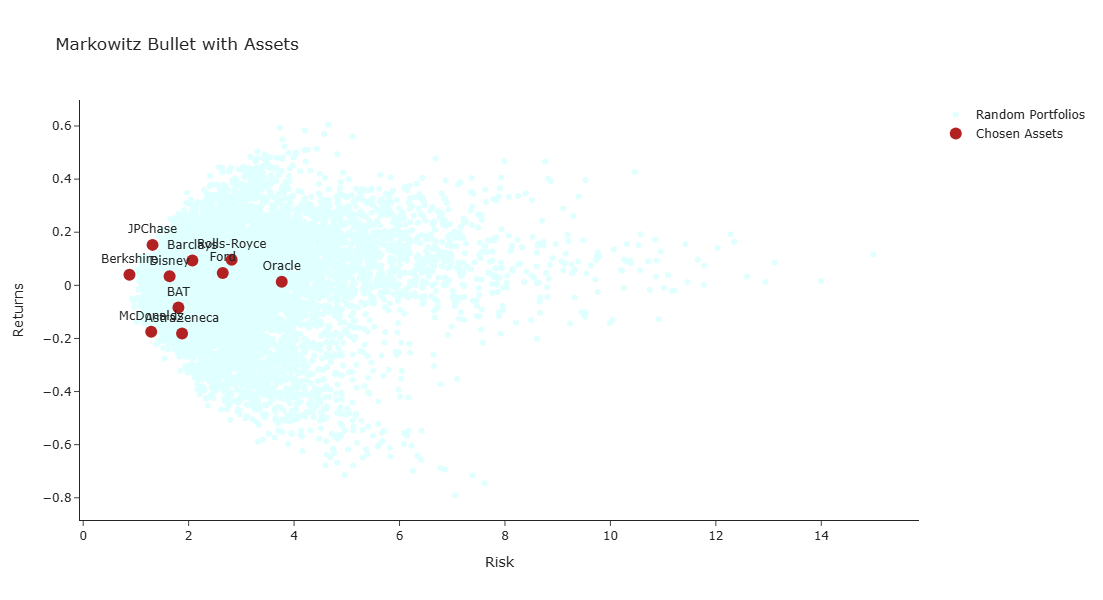

In [57]:
fig = go.Figure()

fig.add_trace(go.Scatter(x = risks, y = returns, mode = 'markers', name = 'Random Portfolios',
              marker = dict(color = 'lightcyan'))
)

fig.add_trace(
    go.Scatter(x = asset_risks, y = asset_returns, mode = 'markers + text', name = 'Chosen Assets',
              marker = dict(color = 'firebrick', size = 12), text = assets.index, textposition = 'top center')
)

fig.update_layout(height = 600, width = 1100, template = 'simple_white',
                  title = dict(text = 'Markowitz Bullet with Assets'), xaxis = dict(title = dict(text = 'Risk')), 
                  yaxis = dict(title = dict(text = 'Returns'))
                )

fig.show()

# Min/Max Return Optimization

<br>
<div class="alert alert-block alert-info"><b>
To find the minimum and maximum returns for our portfolio we will use linear programming from the Scipy library. In the
code cells below we will define equality constraints, linear coefficients for the equality constraints and we also set
upper and lower bounds so that the percentages returned all equate to 1, as the assets in our portfolio cannot equate to
more than 100%.
</b></div>
</br>

In [19]:
D = len(mean_returns)
A_eq = np.ones((1, D))
b_eq = np.ones(1)

In [20]:
bounds = [(-0.5, None)] * D
bounds

[(-0.5, None),
 (-0.5, None),
 (-0.5, None),
 (-0.5, None),
 (-0.5, None),
 (-0.5, None),
 (-0.5, None),
 (-0.5, None),
 (-0.5, None),
 (-0.5, None)]

In [21]:
min_results = linprog(mean_returns, A_eq = A_eq, b_eq = b_eq, bounds = bounds)
min_results

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -1.1065263789930528
              x: [-5.000e-01 -5.000e-01 -5.000e-01 -5.000e-01 -5.000e-01
                  -5.000e-01 -5.000e-01 -5.000e-01  5.500e+00 -5.000e-01]
            nit: 0
          lower:  residual: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              6.000e+00  0.000e+00]
                 marginals: [ 3.337e-01  1.952e-01  6.889e-03  2.280e-01
                              2.153e-01  2.210e-01  2.751e-01  2.775e-01
                              0.000e+00  9.778e-02]
          upper:  residual: [       inf        inf        inf        inf
                                    inf        inf        inf        inf
                                    inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
        

In [22]:
min_results.x.sum()

1.0

In [23]:
min_return = min_results.fun
min_return

-1.1065263789930528

<br>
<div class="alert alert-block alert-info"><b>
In the code cells above we used the use the linprog function to minimize our returns. We parse in our coefficients (mean returns),
our equality constraints, linear coeffecients and the bounds we set earlier. Our optimization was successful and the x variable
it returns is the optimial weights of our portfolio - we can see they add up to 1.
<br></br>
In the code cells below, we find the maximum returns and the only changes parsed in to our optimization function is that we
negate our c-vector which is the mean returns we calculated earlier. We will negate the optimal value (fun:) to get the
absolute value from our program. We can see that our min and max returns are between -1.1 and 0.9 respectively.
</b></div>
</br>

In [24]:
max_results = linprog(-mean_returns, A_eq = A_eq, b_eq = b_eq, bounds = bounds)
max_results

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -0.8953822974195781
              x: [ 5.500e+00 -5.000e-01 -5.000e-01 -5.000e-01 -5.000e-01
                  -5.000e-01 -5.000e-01 -5.000e-01 -5.000e-01 -5.000e-01]
            nit: 0
          lower:  residual: [ 6.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00  0.000e+00]
                 marginals: [ 0.000e+00  1.385e-01  3.268e-01  1.057e-01
                              1.184e-01  1.126e-01  5.857e-02  5.614e-02
                              3.337e-01  2.359e-01]
          upper:  residual: [       inf        inf        inf        inf
                                    inf        inf        inf        inf
                                    inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
        

In [25]:
max_results.x.sum()

1.0

In [26]:
max_return = -max_results.fun
max_return

0.8953822974195781

In [27]:
print('Minimum Return:', round(min_results.fun, 1))
print('Maximum Return:', round(-max_results.fun, 1))

Minimum Return: -1.1
Maximum Return: 0.9


# Mean-Variance Optimization

<br>
<div class="alert alert-block alert-info"><b>
Mean-Variance Optimization is also known as Modern Portfolio Theory and is a framework for maximizing the expected
returns of a portfolios assets given its level of risk. Below we will essentially walk through every possible return
of our portfolio, trying to achieve the minimal risk, and will use 100 steps/points to find the minimal risk.
</b></div>
</br>

In [28]:
N = 100
target_returns = np.linspace(min_return, max_return, num = N)
target_returns

array([-1.10652638, -1.08630508, -1.06608378, -1.04586248, -1.02564118,
       -1.00541988, -0.98519858, -0.96497728, -0.94475598, -0.92453468,
       -0.90431338, -0.88409208, -0.86387078, -0.84364948, -0.82342818,
       -0.80320688, -0.78298558, -0.76276428, -0.74254298, -0.72232168,
       -0.70210038, -0.68187908, -0.66165778, -0.64143648, -0.62121518,
       -0.60099388, -0.58077259, -0.56055129, -0.54032999, -0.52010869,
       -0.49988739, -0.47966609, -0.45944479, -0.43922349, -0.41900219,
       -0.39878089, -0.37855959, -0.35833829, -0.33811699, -0.31789569,
       -0.29767439, -0.27745309, -0.25723179, -0.23701049, -0.21678919,
       -0.19656789, -0.17634659, -0.15612529, -0.13590399, -0.11568269,
       -0.09546139, -0.07524009, -0.05501879, -0.03479749, -0.01457619,
        0.00564511,  0.02586641,  0.04608771,  0.06630901,  0.08653031,
        0.10675161,  0.12697291,  0.14719421,  0.16741551,  0.18763681,
        0.20785811,  0.22807941,  0.24830071,  0.268522  ,  0.28

In [29]:
def get_portfolio_variance(weights):
    return weights.dot(covariance).dot(weights)

In [30]:
def target_return_constraint(weights, target):
    return weights.dot(mean_returns) - target

In [31]:
def portfolio_constraint(weights):
    return weights.sum() - 1

In [32]:
constraints = [{
    'type': 'eq',
    'fun': target_return_constraint,
    'args': [target_returns[0]],
},
               {
    'type': 'eq',
    'fun': portfolio_constraint,
               }]

In [33]:
minvar_results = minimize(
    fun = get_portfolio_variance,
    x0 = np.ones(D) / D,
    method = 'SLSQP',
    constraints = constraints,
)
minvar_results

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 23.009943752321934
           x: [-1.711e+00  4.753e-01  3.322e+00 -8.284e-02 -9.793e-01
               -1.357e+00  2.638e-01 -1.454e-01  9.333e-01  2.812e-01]
         nit: 14
         jac: [-5.183e+00  4.486e-01  8.108e+00 -8.842e-01 -3.683e-01
               -6.018e-01 -2.800e+00 -2.899e+00  8.388e+00  4.411e+00]
        nfev: 164
        njev: 14
 multipliers: [-4.067e+01  1.013e+00]

<br>
<div class="alert alert-block alert-info"><b>
In the code cells above we define 3 functions. First function is to get the variance of our portfolio, the second function
is to get the constraint of our target return - works as an equality constraint and should return 0 if the constraint is
met. The third function is also a constraint that specifies that the weights of our portfolio must sum up to 1. We then also
create a pre-defined list of constraints to parse into the optimization function. The first constraint is the objective function
or the target return for our portfolio and the second constraint is our portfolio constraint that makes sure our weights equate to 1.
</b></div>
</br>

In [34]:
minvar_results.x.sum()

1.0000000000000004

In [35]:
minvar_results = minimize(
    fun = get_portfolio_variance,
    x0 = np.ones(D) / D,
    method = 'SLSQP',
    constraints = constraints,
    bounds = bounds,
)
minvar_results

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 112.59143803990462
           x: [-5.000e-01 -5.000e-01 -5.000e-01 -5.000e-01 -5.000e-01
               -5.000e-01 -5.000e-01 -5.000e-01  5.500e+00 -5.000e-01]
         nit: 3
         jac: [-3.530e+00 -3.712e+01  5.759e+00 -9.629e+00 -2.250e+00
                4.722e-01 -6.601e+00 -1.131e+01  3.597e+01  9.469e+00]
        nfev: 30
        njev: 2
 multipliers: [-4.384e+03 -7.590e+02]

In [36]:
minvar_results.x.sum()

1.0000000000001066

In [37]:
optimized_risks = []
for target in target_returns:
    constraints[0]['args'] = [target]

    minvar_results = minimize(
    fun = get_portfolio_variance,
    x0 = np.ones(D) / D,
    method = 'SLSQP',
    constraints = constraints,
    bounds = bounds,
    )

    optimized_risks.append(np.sqrt(minvar_results.fun))
    if minvar_results.status != 0:
        print(minvar_results)

<br>
<div class="alert alert-block alert-info"><b>
In the code cells above we loop through all of our target returns - this will create our optimized risks and we will use
this to draw the Efficient Frontier. The Efficient Frontier is a set of optimal investment assets which offers the highest
expected returns with the lowest amount of risk.
<br></br>
In the plot below we can see that the Efficient Frontier is drawn around the Markowitz Bullet. The Frontier is the top line
of the Markowitz Bullet as these represent the assets with the highest returns, with different levels of risk. The negative
side (bottom of the bullet) represents assets with low returns and high levels of risk.
</b></div>
</br>

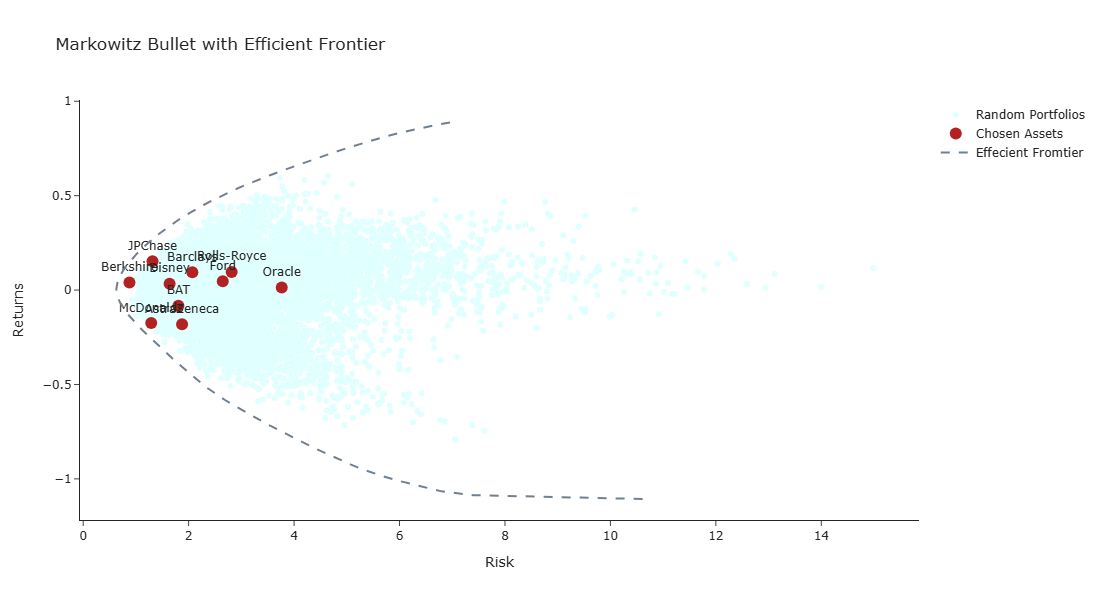

In [54]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(x = risks, y = returns, mode = 'markers', name = 'Random Portfolios',
              marker = dict(color = 'lightcyan'))
)

fig.add_trace(
    go.Scatter(x = asset_risks, y = asset_returns, mode = 'markers + text', name = 'Chosen Assets',
              marker = dict(color = 'firebrick', size = 12), text = assets.index, textposition = 'top center')
)

fig.add_trace(
    go.Scatter(x = optimized_risks, y = target_returns, name = 'Effecient Fromtier', line = dict(color = 'slategrey', dash = 'dash'))
)

fig.update_layout(height = 600, width = 1100, template = 'simple_white',
                  title = dict(text = 'Markowitz Bullet with Efficient Frontier'), xaxis = dict(title = dict(text = 'Risk')), 
                  yaxis = dict(title = dict(text = 'Returns'))
                )

fig.show()

# Global Minimum Variance (GMV)
# Maximum Sharpe Ratio
# Tangency Portfolio

<br>
<div class="alert alert-block alert-info"><b>
The Global Minimum Variance (GMV) is the end point or tip of the bullet which represents the lowest point of risk without
expected returns. The Maximum Sharpe Ratio represents the optimal point of excess return based on the amount of risk - it
also uses the risk free rate which is the return of a portfolio with zero risk of financial loss - these tend to be low risk/
low equity government bonds in most countries. The Tangency Portfolio/Line is the ideal mix of assets with variable risk
and has the highest Sharpe Ratio (excess returns). All 3 of these points are plotted below and they all occur on the Efficient
Frontier. These are points where we would want our assets to occur and would help make decisions about which assets to include
in our portfolio, our assets cannot occur exactly on these points but the closer they are the better.
</b></div>
</br>

In [39]:
gmv_results = minimize(
    fun = get_portfolio_variance,
    x0 = np.ones(D) / D,
    method = 'SLSQP',
    constraints = {
        'type': 'eq',
        'fun': portfolio_constraint,
    },
    bounds = bounds
)
gmv_results

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.39611123613385635
           x: [ 1.293e-01  6.421e-02  1.228e-01  3.863e-02 -3.558e-02
                4.916e-01  1.333e-01 -9.098e-02  5.459e-02  9.211e-02]
         nit: 11
         jac: [ 7.922e-01  7.922e-01  7.922e-01  7.922e-01  7.922e-01
                7.922e-01  7.922e-01  7.922e-01  7.922e-01  7.922e-01]
        nfev: 131
        njev: 11
 multipliers: [ 7.922e-01]

In [40]:
gmv_risk = np.sqrt(gmv_results.fun)
gmv_weights = gmv_results.x
gmv_returns = gmv_weights.dot(mean_returns)

In [41]:
risk_free_rate = 0.0438 / 252
mc_best_w = None
mc_best_sr = float('-inf')

for i, (mc_risks, mc_returns) in enumerate(zip(risks, returns)):
    sr = (mc_returns - risk_free_rate) / mc_risks
    if sr > mc_best_sr:
        mc_best_sr = sr
        mc_best_w = random_weights[i]
print('Best Weights:', mc_best_w)
print('Best Sharpe Ratio:', mc_best_sr)

Best Weights: [ 1.37177303 -0.06137641 -0.47087707  0.34199973  0.14917032  0.42914448
 -0.06136531 -0.28381253 -0.18853977 -0.22611648]
Best Sharpe Ratio: 0.17665565120718799


In [42]:
opt_risk = np.sqrt(mc_best_w.dot(covariance).dot(mc_best_w))
opt_ret = mean_returns.dot(mc_best_w)

x1 = 0
y1 = risk_free_rate
x2 = opt_risk
y2 = opt_ret

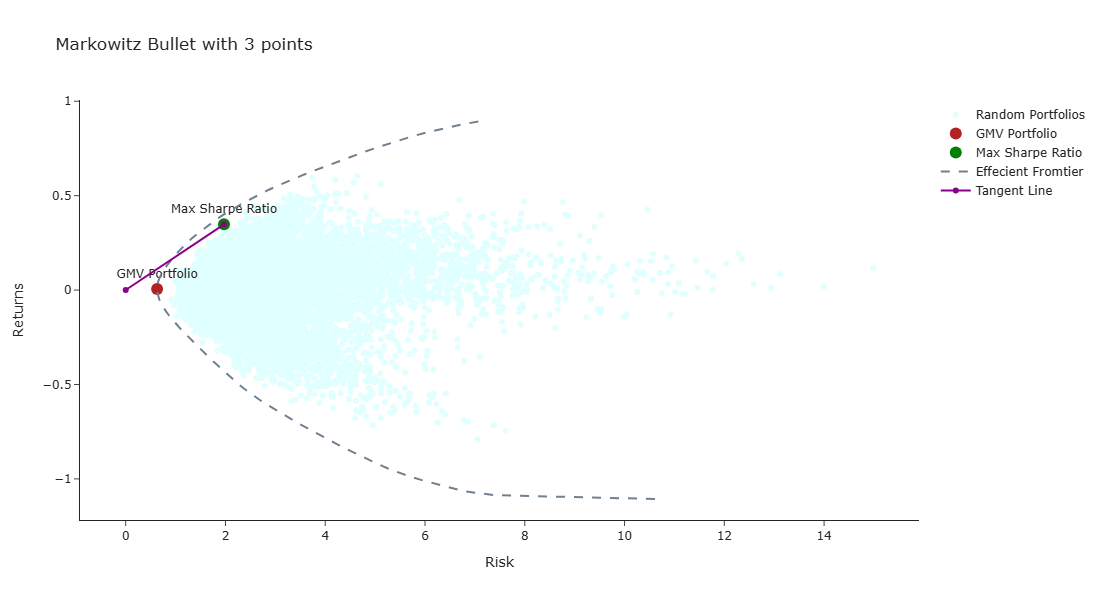

In [56]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(x = risks, y = returns, mode = 'markers', name = 'Random Portfolios',
              marker = dict(color = 'lightcyan'))
)

fig.add_trace(
    go.Scatter(x = [gmv_risk], y = [gmv_returns], mode = 'markers + text', name = 'GMV Portfolio',
              marker = dict(color = 'firebrick', size = 12), text = 'GMV Portfolio', textposition = 'top center')
)

fig.add_trace(
    go.Scatter(x = [opt_risk], y = [opt_ret], mode = 'markers + text', name = 'Max Sharpe Ratio',
              marker = dict(color = 'green', size = 12), text = 'Max Sharpe Ratio', textposition = 'top center')
)

fig.add_trace(
    go.Scatter(x = optimized_risks, y = target_returns, name = 'Effecient Fromtier', line = dict(color = 'slategrey', dash = 'dash'))
)


fig.add_trace(
    go.Scatter(x = [x1, x2], y = [y1, y2], name = 'Tangent Line', line = dict(color = 'darkmagenta'))
)

fig.update_layout(height = 600, width = 1100, template = 'simple_white',
                  title = dict(text = 'Markowitz Bullet with 3 points'), xaxis = dict(title = dict(text = 'Risk')), 
                  yaxis = dict(title = dict(text = 'Returns'))
                )

fig.show()

# Portfolio Allocation

<br>
<div class="alert alert-block alert-info"><b>
In this section we will use the same methods we did previously but the goal would be to optimise the weights of our
10 asset portfolio and use those weights to allocate the percentage we should have in our portfolio. This would be
based on minimizing the risk for the entire portfolio, which is all the assets in our portfolio. The assets chosen
are random but are from different industries and should showcase different levels of risk and returns, we will see
the percentage of assets we are expected to hold based on their optimized weights in a pie chart. It is also important
to remember that the percentage may change everyday or every time the notebook is run as yfinance adjusts/updates data.
</b></div>
</br>

In [44]:
def get_port_risk(weights):
    returns_df = merged.pct_change(1).dropna()
    num_stocks = len(returns_df.columns)

    var_covar = returns_df.cov()

    var_port = np.dot(np.transpose(weights), np.dot(var_covar, weights))
    stdev_port = np.sqrt(var_port)
    stdev_annual = stdev_port * np.sqrt(252)

    return stdev_annual

In [45]:
num_stocks = len(merged.columns)
init_weights = [1 / num_stocks] * num_stocks

In [46]:
bounds_port = tuple((0, 1) for i in range(num_stocks))
cons_port = ({'type': 'eq', 'fun': lambda x : np.sum(x) - 1})

In [47]:
port_results = minimize(fun = get_port_risk,
                        x0 = init_weights,
                        bounds = bounds_port,
                        constraints = cons_port
)

port_results

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.10461292451555523
           x: [ 1.276e-01  6.339e-02  9.177e-02  2.091e-02  2.071e-17
                4.778e-01  5.516e-02  2.851e-17  6.050e-02  1.029e-01]
         nit: 9
         jac: [ 1.043e-01  1.049e-01  1.047e-01  1.048e-01  1.263e-01
                1.049e-01  1.039e-01  1.895e-01  1.043e-01  1.039e-01]
        nfev: 100
        njev: 9
 multipliers: [ 1.046e-01]

In [48]:
get_port_risk(init_weights)

0.15478232610433

In [49]:
optimised_weights = pd.DataFrame(port_results['x'])
optimised_weights.index = merged.columns
optimised_weights.rename(columns = {optimised_weights.columns[0]: 'weights'}, inplace = True)

In [50]:
optimised_weights['weights_rounded'] = optimised_weights.apply(lambda x: round(x, 3))
optimised_weights

,weights,weights_rounded
JPChase,1.275868e-01,0.128
Oracle,6.338593e-02,0.063
McDonalds,9.176563e-02,0.092
Ford,2.090793e-02,0.021
Disney,2.070826e-17,0.000
Berkshire,4.778221e-01,0.478
Barclays,5.516291e-02,0.055
Rolls-Royce,2.851452e-17,0.000
AstraZeneca,6.049945e-02,0.060
BAT,1.028693e-01,0.103


In [51]:
optimised_weights['allocation'] = optimised_weights['weights_rounded'].sort_values(ascending = False).cumsum()
optimised_weights = optimised_weights.sort_values(by = 'allocation')
optimised_weights

,weights,weights_rounded,allocation
Berkshire,4.778221e-01,0.478,0.478
JPChase,1.275868e-01,0.128,0.606
BAT,1.028693e-01,0.103,0.709
McDonalds,9.176563e-02,0.092,0.801
Oracle,6.338593e-02,0.063,0.864
AstraZeneca,6.049945e-02,0.060,0.924
Barclays,5.516291e-02,0.055,0.979
Ford,2.090793e-02,0.021,1.000
Disney,2.070826e-17,0.000,1.000
Rolls-Royce,2.851452e-17,0.000,1.000


<br>
<div class="alert alert-block alert-info"><b>
In the code cells above we run the optimization similar to what we did earlier but now we are only interested
in optimizing the weights for our assets based on their risk - allocation is based solely on optimized risk and
not the expected returns as well. The allocation column shows the cumulative weights (percentage) of the assets
we would hold in our portfolio. It can be seen that 98% of our allocation is given to 7 assets and the last 3 assets
make up a very small percentage of our portfolio.
</b></div>
</br>

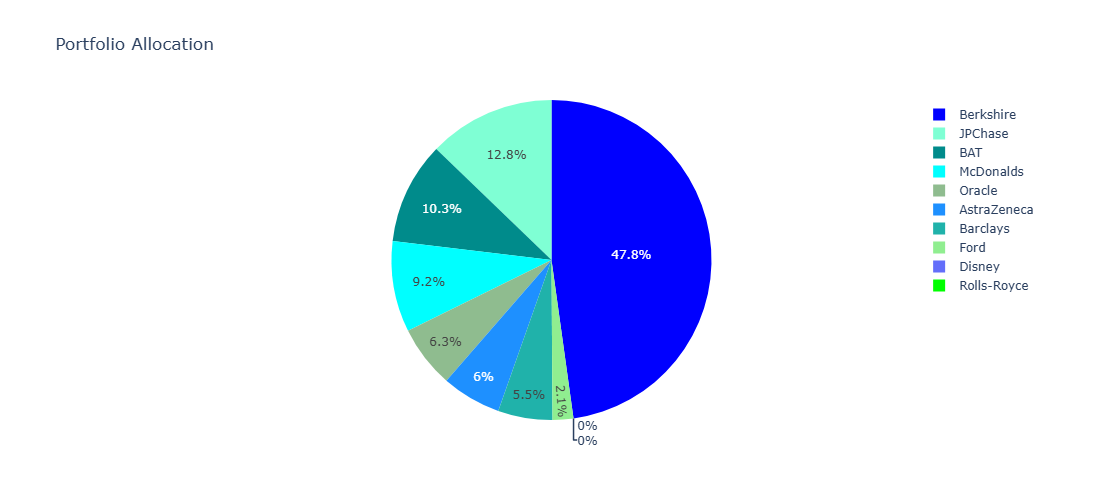

In [52]:
fig = px.pie(values = optimised_weights['weights_rounded'], names = optimised_weights.index,
             title = 'Portfolio Allocation', color = optimised_weights.index,
            color_discrete_map = {'Berkshire': 'blue',
                                  'McDonalds': 'aqua',
                                  'JPChase': 'aquamarine',
                                  'BAT': 'darkcyan',
                                  'Oracle': 'darkseagreen',
                                  'AstraZeneca': 'dodgerblue',
                                  'Barclays': 'lightseagreen',
                                  'Ford': 'lightgreen',
                                  'Disney': 'turqiose',
                                  'Rolls-Royce': 'lime'})
fig.update_layout(height = 500, width = 900)
fig.show()